# Monthly count of days with maximum near-surface air temperature above 35 degC

This Jupyter Notebook calculates the index **tx35** (Monthly count of days with maximum near-surface (2-metre) air temperature above 35 degC) for the CMIP6-CMCC_ESM2 model.

For quick demonstration purposes, only one year from the future period (the year 2080) is calculated for a specific region (Spain).

First, the raw CMIP6 model is downloaded from the CDS, then the index is calculated, and the results are compared with the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview), also downloaded from the CDS.

### Load Python packages and clone and install the c3s-atlas GitHub repository from the ecmwf-projects

Clone (`git clone`) the [c3s-atlas](https://github.com/ecmwf-projects/c3s-atlas) repository and install them (`pip install -e .`).

Further details on how to clone and install the repository are available in the [requirements section](https://github.com/ecmwf-projects/c3s-atlas?tab=readme-ov-file#requirements)

In [1]:
import cdsapi
import os
from pathlib import Path
import xarray as xr
import xclim
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


from c3s_atlas.utils import (
    extract_zip_and_delete,
    plot_month
)

from c3s_atlas.fixers import (
    apply_fixers
)
#import c3s_atlas.interpolation as xesmfCICA


### Download climate data with the CDS API
To reduce data size and download time, a geographical subset focusing on a apecific area within the European region (Spain) is selected.

- Catalogue: [CMIP6 climate projections](https://cds.climate.copernicus.eu/datasets/projections-cmip6?tab=overview)

In [2]:
# configure your .cdsapirc

cdsapi_url= "https://cds.climate.copernicus.eu/api"
cdsapi_key= ""

In [3]:
# c = cdsapi.Client(url=cdsapi_url, key=cdsapi_key)

c = cdsapi.Client()

2025-09-29 20:59:19,742 INFO [2025-09-03T00:00:00] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.
2025-09-29 20:59:19,744 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


> ⚠️ **Warning: Exposed API Credentials**
>
> For security reasons, it is not recommended to hardcode your Copernicus Climate Data Store (CDS) API credentials — such as `cdsapi_url` and `cdsapi_key` — directly in notebooks.
>
> Instead, it is best to store them securely in a `.cdsapirc` file located in your home directory.
>
> 📄 More info: [CDS API - How to use the API](https://cds.climate.copernicus.eu/how-to-api)

In [4]:
# define some global attributes for the CDS-API
CMIP6_years = {
    "ssp5_8_5": ["2080"],
}
# variables
variables = {
    'tx': 'daily_maximum_near_surface_air_temperature',
}
# directory to download the files
file_dest_CMIP6 = Path('../data/CMIP6')

In [5]:
months = [
    '01', '02', '03',
    '04', '05', '06',
    '07', '08', '09',
    '10', '11', '12'
]
        
days = [
    '01', '02', '03',
    '04', '05', '06',
    '07', '08', '09',
    '10', '11', '12',
    '13', '14', '15',
    '16', '17', '18',
    '19', '20', '21',
    '22', '23', '24',
    '25', '26', '27',
    '28', '29', '30', '31'
]

In [6]:
os.makedirs(file_dest_CMIP6, exist_ok=True)

for experiment in CMIP6_years.keys():
    for year in CMIP6_years[experiment]:
        for var in variables.keys():
            path_zip = file_dest_CMIP6 / f"CMIP6_{var}_{experiment}_{year}.zip"
            c.retrieve(
                'projections-cmip6',
                {
                    'format': 'zip',
                    'temporal_resolution': 'daily',
                    'variable': variables[var],
                    'experiment': experiment,
                    'model': 'cmcc_esm2',
                    'year': year,
                    'month': months,
                    'day': days,
                },
                path_zip)
            # Extract zip file into the specified directory and remove zip
            extract_zip_and_delete(path_zip) 

2025-09-29 20:59:27,163 INFO Request ID is 324dcac8-28eb-44b6-ae36-e829fabc44e1
2025-09-29 20:59:27,256 INFO status has been updated to accepted
2025-09-29 20:59:41,123 INFO status has been updated to successful


ccf265c8648069b73366f399ccd83090.zip:   0%|          | 0.00/44.5M [00:00<?, ?B/s]

provenance.json
provenance.png
tasmax_day_CMCC-ESM2_ssp585_r1i1p1f1_gn_20800101-20801231.nc


### Load files with xarray
- https://docs.xarray.dev/en/stable/

In [7]:
# load files
ds = xr.open_dataset(file_dest_CMIP6 / "CMIP6_tx_ssp5_8_5_2080.nc")

### Homogenization
Once the data is downloaded from the CDS it undergoes a process of homogenization: 
- The metadata of the **spatial coordinates** is homogenised to use standard names, in particular [lon, lat].
- Fix any non-standard **calendars** used in the data. This typically involves converting the calendars to the CF standard calendar (Mixed Gregorian/Julian) commonly used in climate data. 
- Convert the **units** of the data to a common format (e.g. Celsius for temperature). This prevents us from working with the same variables in different units, for example.
- Convert the **longitude** values from the [0, 360] format to the [-180, 180] one. This is done to ensure that the longitude variable is common between the different datasets.
- **Aggregated to the required temporal resolution**. For example, hourly datasets (such as ERA5, ERA5-Land, WFDE5, etc.) will be resampled to daily resolution. This involves using a temporal aggregation method, such as taking the maximum or minimum value for a given variable. As part of this last step, some variable transformations are necessarily applied. For instance, fluxes variables in ERA5 are accumulated, and therefore, the last hour of the day represent daily accumulations. To mention another case, the surface wind is computed as a combination of both the u- and v-components.

In [8]:
project_id = "cmip6"
variable = 'tasmax'
var_mapping = {
            "dataset_variable": {"tasmax": "data"},
            "aggregation": {"data": "mean"},
        }

In [9]:
ds = apply_fixers(ds, variable, project_id, var_mapping)

2025-09-29 20:59:57,661 — Homogenization-fixers — INFO — Dataset has already the correct names for its coordinates
2025-09-29 20:59:57,687 — Homogenization-fixers — INFO — Fixing calendar for <xarray.Dataset> Size: 81MB
Dimensions:    (time: 365, bnds: 2, lat: 192, lon: 288)
Coordinates:
  * time       (time) object 3kB 2080-01-01 12:00:00 ... 2080-12-31 12:00:00
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 6kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    tasmax     (time, lat, lon) float32 81MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60225.0
    branch_time_in_parent:  60225.0


### Calculate index (tx35) and aggregate to monthly (MS) temporal resolution using xclim

[xclim](https://xclim.readthedocs.io/en/stable/) is an operational Python library for climate services, providing a framework for constructing custom climate indicators and indices.

In [10]:
da_tx35 = xclim.indices.tx_days_above(ds['tasmax'], thresh='35.0 degC', 
                                      freq='MS', op='>')

"freq" attribute indicates output time frequency following [pandas timeserie codes](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects)

In [11]:
# Convert DataArray to Dataset with specified variable name
ds_tx35 = da_tx35.to_dataset(name='tx35')

### Interpolation to a common and regular grid using [xESMF](https://xesmf.readthedocs.io/en/stable/)
A wrapper for the [xESMF](https://xesmf.readthedocs.io/en/stable/) Python package was developed within the framework of the C3S Atlas project to extend its functionalities to all datasets (regular, curvilinear, etc.)

In [16]:
# interpolate data
int_attr = {'interpolation_method' : 'conservative_normed', 
            'lats' : np.arange(-89.5, 90.5, 1),
            'lons' : np.arange(-179.5, 180.5, 1),
            'var_name' : 'tx35'
}

In [17]:
INTER = xesmfCICA.Interpolator(int_attr)

In [ ]:
ds_tx35_i = INTER(ds_tx35)

### Interpolation to a common and regular grid using CLISOPS (xESMF)

In [12]:
import clisops.ops as clops

In [22]:
ds_tx35_i = clops.regrid(
    ds_tx35, 
    method="conservative", 
    # grid="2pt5deg", 
    output_type="xarray")[0]
ds_tx35_i

/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/clisops/utils/common.py:65: UserWarning: xarray version >= 2023.3.0 is not supported for regridding operations with cf-time indexed arrays. Please use xarray version < 2023.3.0. For more information, see: https://github.com/pydata/xarray/issues/7794.
  warnings.warn(max_supported_warning)
/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/clisops/utils/common.py:65: UserWarning: xarray version >= 2023.3.0 is not supported for regridding operations with cf-time indexed arrays. Please use xarray version < 2023.3.0. For more information, see: https://github.com/pydata/xarray/issues/7794.
  warnings.warn(max_supported_warning)
/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/clisops/utils/dataset_utils.py:63: UserWarning: No main variable found for dataset '<xarray.Dataset> Size: 8kB
Dimensions:   (lat: 191, lon: 287, bnds: 2)
Coordinates:
  * lat       (lat) float64 2kB -89.53 -88

<xarray.Dataset> Size: 5MB
Dimensions:   (lat: 191, bnds: 2, lon: 287, time: 12)
Coordinates:
    lat_bnds  (lat, bnds) float64 3kB -90.0 -89.06 -89.06 ... 89.06 89.06 90.0
    lon_bnds  (lon, bnds) float64 5kB -179.4 -178.1 -178.1 ... 178.1 178.1 179.4
  * lat       (lat) float64 2kB -89.53 -88.59 -87.64 -86.7 ... 87.64 88.59 89.53
  * lon       (lon) float64 2kB -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
  * time      (time) datetime64[ns] 96B 2080-01-01 2080-02-01 ... 2080-12-01
Dimensions without coordinates: bnds
Data variables:
    tx35      (time, lat, lon) float64 5MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    grid:                regional regular_lat_lon 191x287 (54817 cells) grid.
    grid_label:          gr
    regrid_operation:    conservative_192x288_191x287
    regrid_tool:         xESMF_v0.8.10
    regrid_weights_uid:  adfe147a300839d5e75a0558021b3055_79b4994c22c8dd6ff07...

### Compare the results with the "Gridded dataset underpinning the Copernicus Interactive Climate Atlas"

- Catalogue: [Gridded dataset underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview)

In [23]:
project = "CMIP6"
scenario = "ssp585"
var = 'tx35'
# directory to download the files
dest = Path('./data/CMIP6')
os.makedirs(dest, exist_ok=True)

##### Download SSP scenario

In [15]:
filename = 'tx35_CMIP6_ssp585_mon_201501-210012.zip'
dataset = "multi-origin-c3s-atlas"
request = {
    "origin": "cmip6",
    "experiment": "ssp5_8_5",
    "period": "2015-2100",
    "variable": "monthly_extreme_hot_days",
    "bias_adjustment": "no_bias_adjustment",
    'area': [44.5, -9.5, 35.5, 3.5]
}

c.retrieve(dataset, request).download(dest / filename)
extract_zip_and_delete(dest / filename) 

2025-09-29 21:01:47,451 INFO [2025-09-24T09:00:00] Help shape the future of the C3S Atlas by letting us know how you use it (including the application, this dataset, the documentation and user tools), and whether there are any additions or improvements you would like to see in the future. Complete the [C3S Atlas User Survey](https://ec.europa.eu/eusurvey/runner/791fd0a8-6c85-0971-4360-b98b2c585843).
2025-09-29 21:01:47,451 INFO Request ID is 1e6aaa0d-e946-48a8-9908-63d243cf9b8c
2025-09-29 21:01:47,558 INFO status has been updated to accepted
2025-09-29 21:01:56,107 INFO status has been updated to running
2025-09-29 21:02:08,962 INFO status has been updated to accepted
2025-09-29 21:02:20,468 INFO status has been updated to successful


b7932a73a7f9117554e765a8df3758c8.zip:   0%|          | 0.00/952k [00:00<?, ?B/s]

provenance.json
provenance.png
tx35_CMIP6_ssp585_mon_20150101-21001201.nc


In [24]:
# load data with xarray
ds_tx35_C3S_Atlas = xr.open_dataset(dest / "tx35_CMIP6_ssp585_mon_201501-210012.nc")

In [25]:
# select a specific member of the ensemble
select_member = [
    str(mem.data) for mem in ds_tx35_C3S_Atlas.member_id if "cmcc-esm2" in str(mem.data).lower()
][0]
print(select_member)

CMCC_CMCC-ESM2_r1i1p1f1


In [26]:
ds_tx35_C3S_Atlas_member_year = ds_tx35_C3S_Atlas.sel(
    member = np.where(ds_tx35_C3S_Atlas.member_id == select_member)[0], 
    time = "2080"
)

#### Plot results for one month
Comparison of the results obtained with present Jupyter notebook and the reference [C3S Atlas Dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) underpinning the C3S Atlas. A geographical subset focusing on Spain is selected to show the results.

In [27]:
zoomin_extent = [-9.5, 3.5, 35.5, 44.5]

/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pingu/miniforge3/envs/regrid-demo/lib/python3.13/site-pac

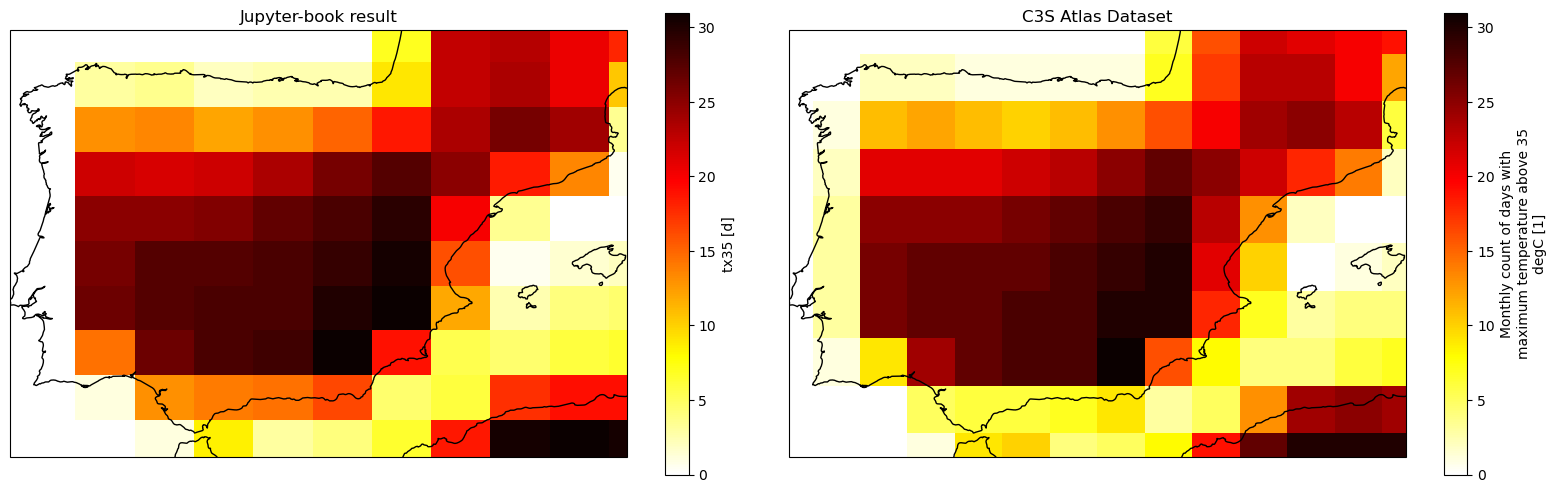

In [28]:
# zoom for Spain
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': proj}, figsize=(20, 6))
# user-tools
plot_month(ax[0], ds_tx35_i, 'tx35', 8, 'Jupyter-book result', 'hot_r')
ax[0].set_extent(zoomin_extent)
# workflow (intermediate dataset)
plot_month(ax[1], ds_tx35_C3S_Atlas_member_year, 'tx35', 8, 'C3S Atlas Dataset', 'hot_r')
ax[1].set_extent(zoomin_extent)
plt.subplots_adjust(wspace=0.01, hspace=0.1) 